In [1]:
import json
from pathlib import Path
from typing import Dict, List

from model_ranking import (
    plot_alpha_sweep_specific_norm,
    plot_performance_vs_transfer_metric_multi_target,
    to_target_transfer_correlations,
    correlation_table,
    load_transfer_metric_results,
)

INFO: P [MainThread] 2026-02-23 10:50:14,782 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
performance_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/AdaBN/transfer_performance_AdaBN_MAP_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]


Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/AdaBN/transfer_AdaBN_Gauss_a001-005_FORG_ARE_scores.json
Processing: Gauss_Consistency_a001-005
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


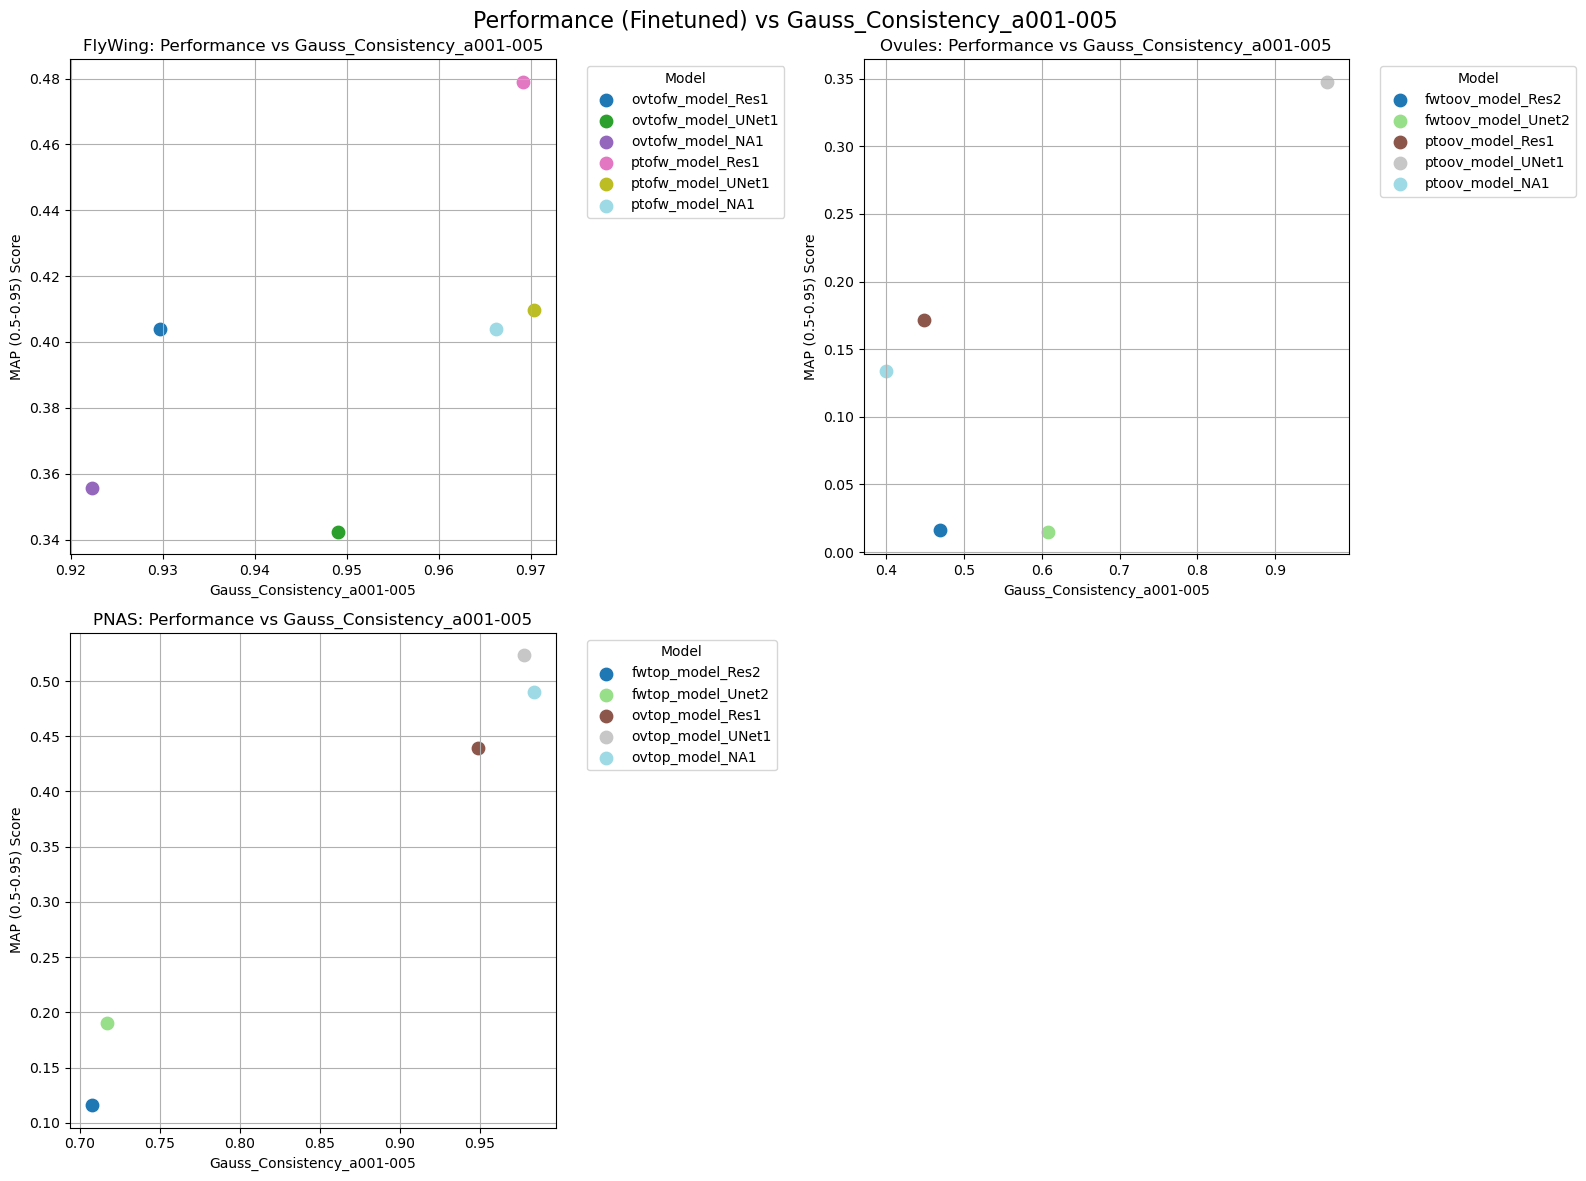

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.47     0.28   0.66        0.18  0.59     0.22
     Ovules   0.00     1.00   0.10        0.97  0.69     0.19
     PNAS     0.80     0.09   0.90        0.07  0.99     0.00
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/AdaBN/transfer_AdaBN_Gauss_a005-01_FORG_ARE_scores.json
Processing: Gauss_Consistency_a005-01
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


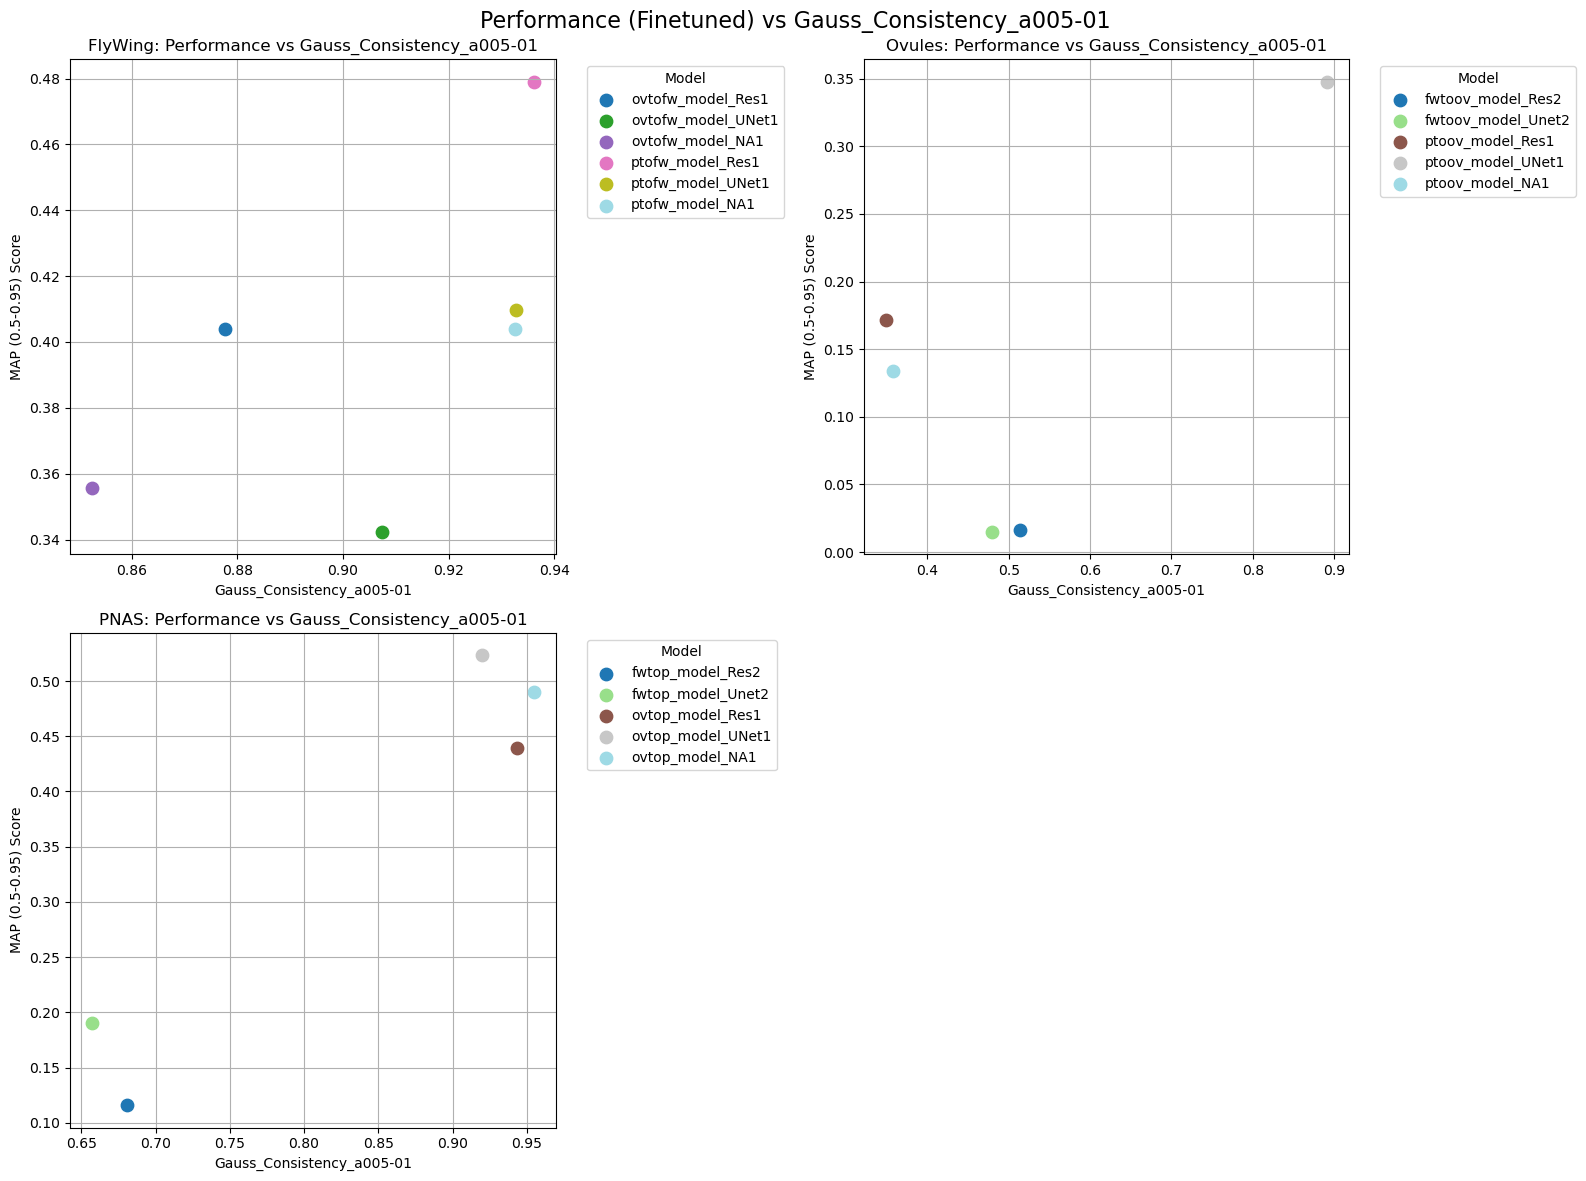

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito FlyWing  0.6     0.15   0.71        0.15  0.59     0.22
     Ovules   0.0     1.00   0.10        1.00  0.65     0.24
     PNAS     0.4     0.50   0.60        0.34  0.96     0.01
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/AdaBN/transfer_AdaBN_Gauss_a01-015_FORG_ARE_scores.json
Processing: Gauss_Consistency_a01-015
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


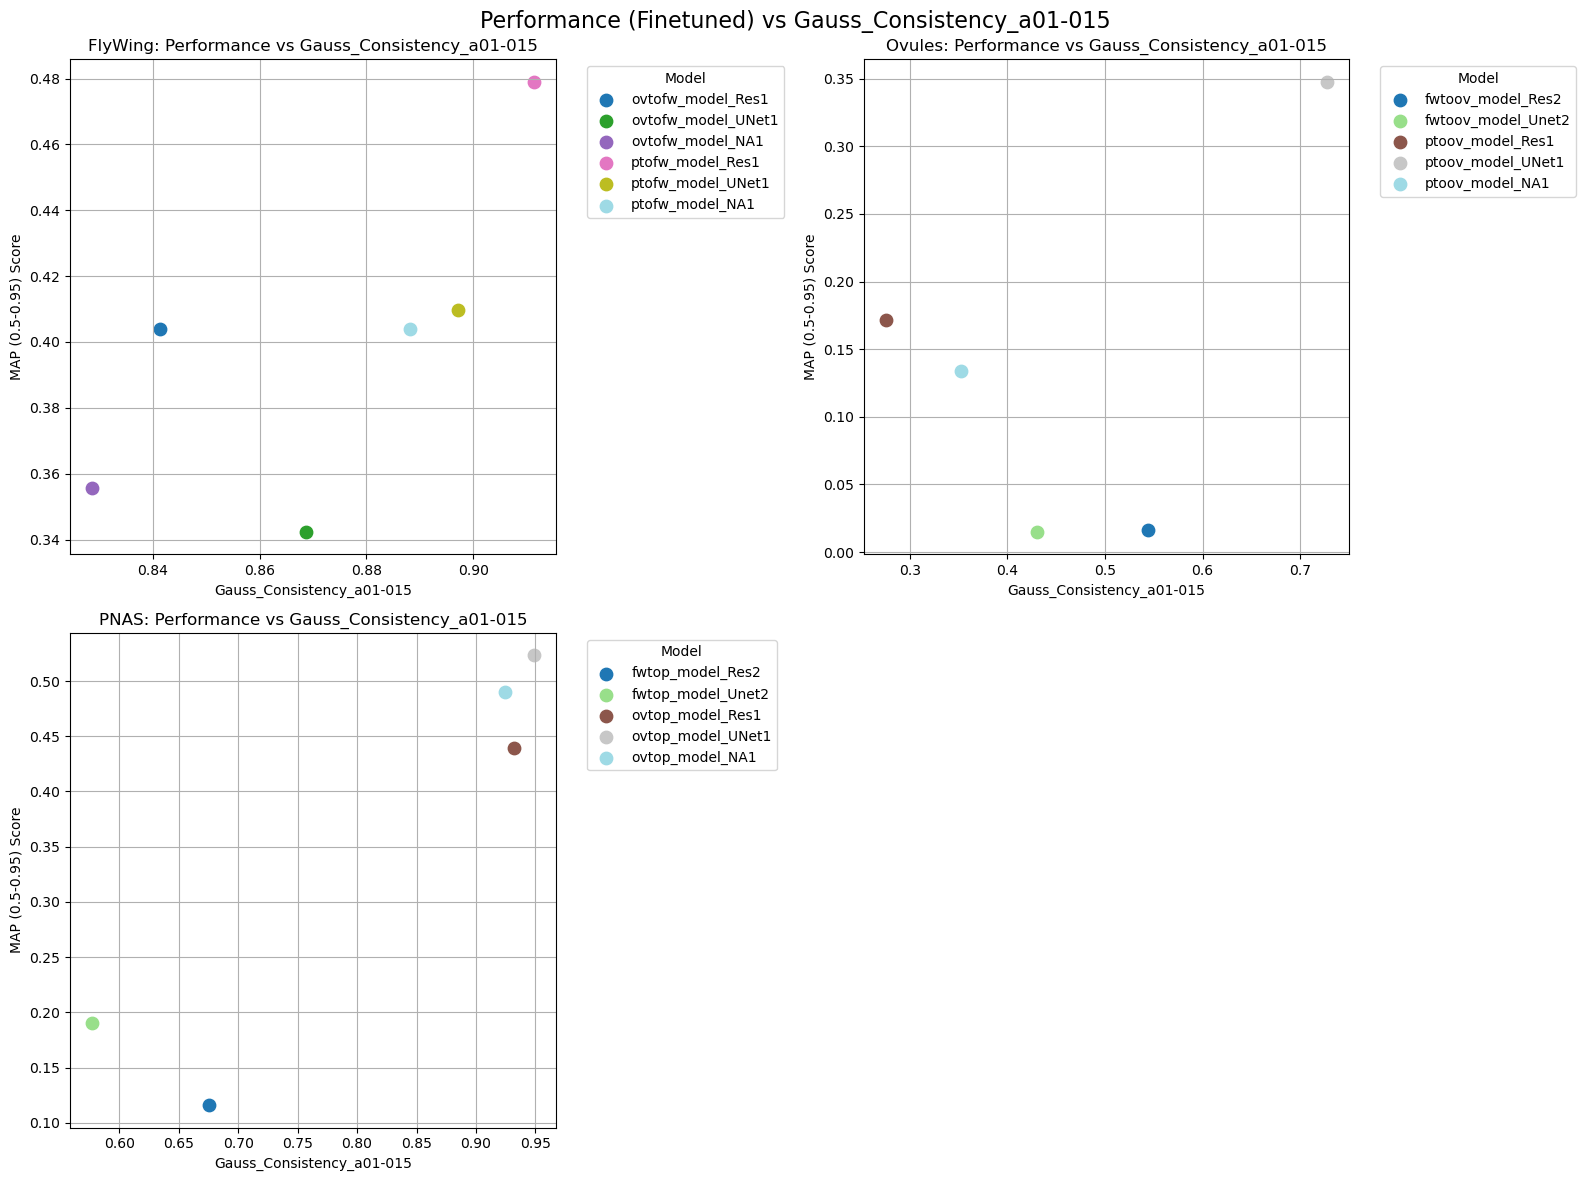

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito FlyWing  0.6     0.15   0.71        0.15  0.69     0.13
     Ovules   0.0     1.00   0.10        0.97  0.45     0.44
     PNAS     0.6     0.23   0.80        0.11  0.93     0.02
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/AdaBN/transfer_AdaBN_Gauss_a015-02_FORG_ARE_scores.json
Processing: Gauss_Consistency_a015-02
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


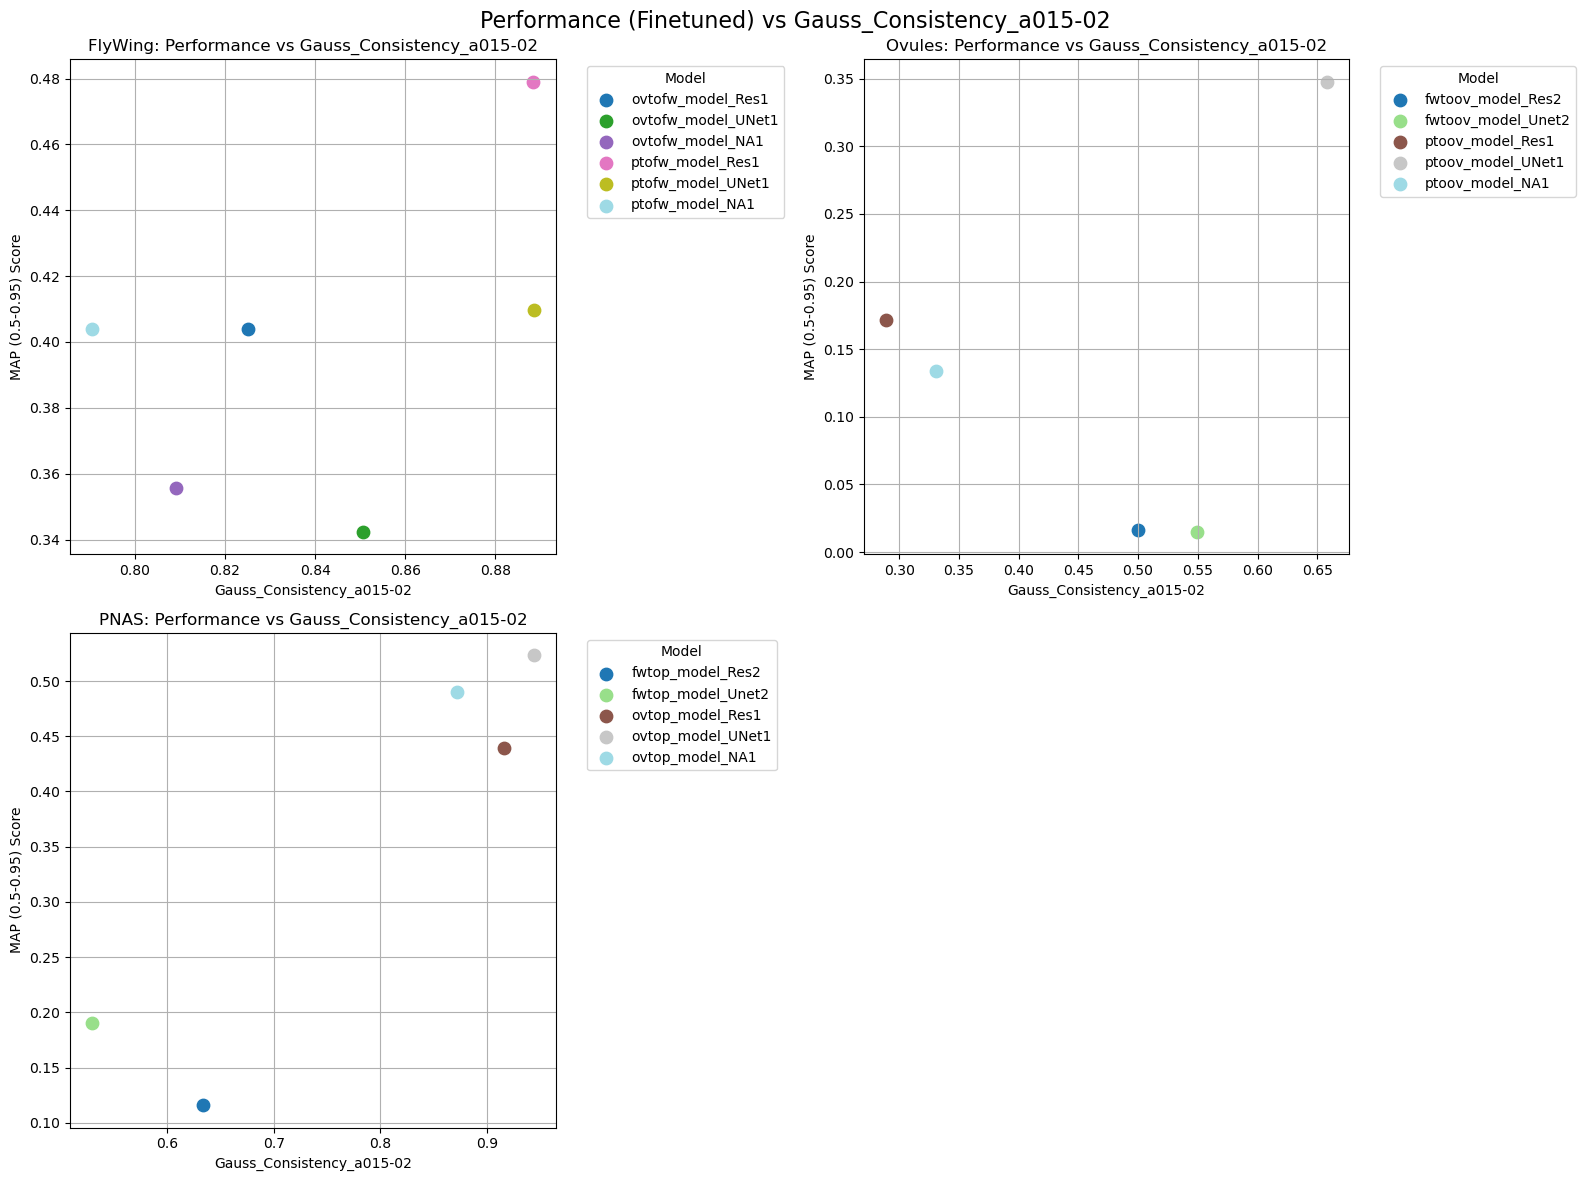

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.33     0.49   0.54        0.29  0.49     0.33
     Ovules  -0.20     0.78   0.00        1.00  0.24     0.69
     PNAS     0.60     0.23   0.80        0.14  0.93     0.02
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/AdaBN/transfer_AdaBN_Gauss_a02-025_FORG_ARE_scores.json
Processing: Gauss_Consistency_a02-025
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


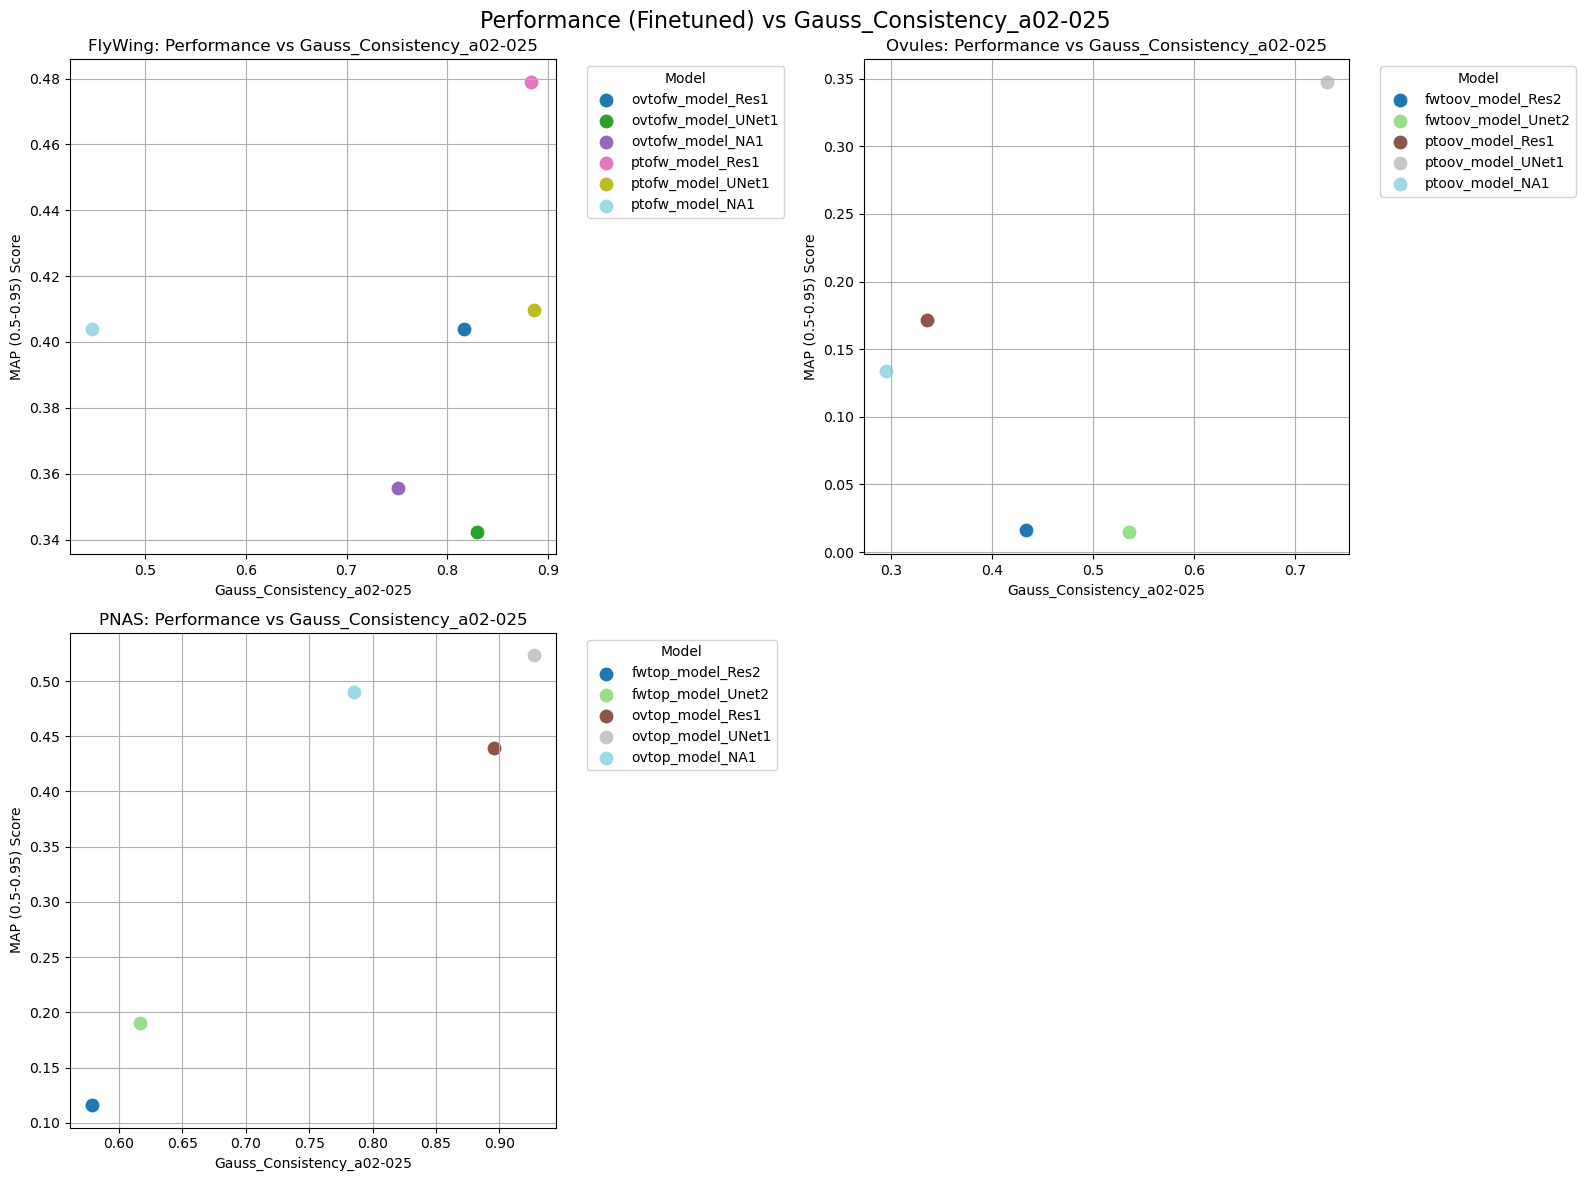

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.33     0.50   0.54        0.31  0.16     0.76
     Ovules   0.00     1.00   0.10        0.95  0.49     0.40
     PNAS     0.80     0.07   0.90        0.06  0.93     0.02


In [6]:
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/AdaBN"
selected_augmentations = ["a001-005", "a005-01", "a01-015", "a015-02", "a02-025"]

for aug in selected_augmentations:
    file_name = f"transfer_AdaBN_Gauss_{aug}_FORG_ARE_scores.json"
    consistency_path = Path(base_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]
    targets = list(consistency_scores.keys())
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=performance_scores,
            transfer_scores=consistency_scores,
            transfer_metric=f"Gauss_Consistency_{aug}",
            finetuned=True,
            invert_transfer_metric=True,
            performance_metric_key="MAP (0.5-0.95)"
        )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consistency_scores,
        performance_per_target=performance_scores,
        invert_transfer_metric=True,
        )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)
            
        

# Combined Plot

In [4]:
performance_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/transfer_performance_scores_with_NORM.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]


In [5]:
consistency_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/transfer_GaussSweep_AllLayers_CMB_05f_05b_consistency_scores_with_NORM.json"
with open(consistency_path, "r") as f:
    consistency_scores = json.load(f)["transfer_scores"]

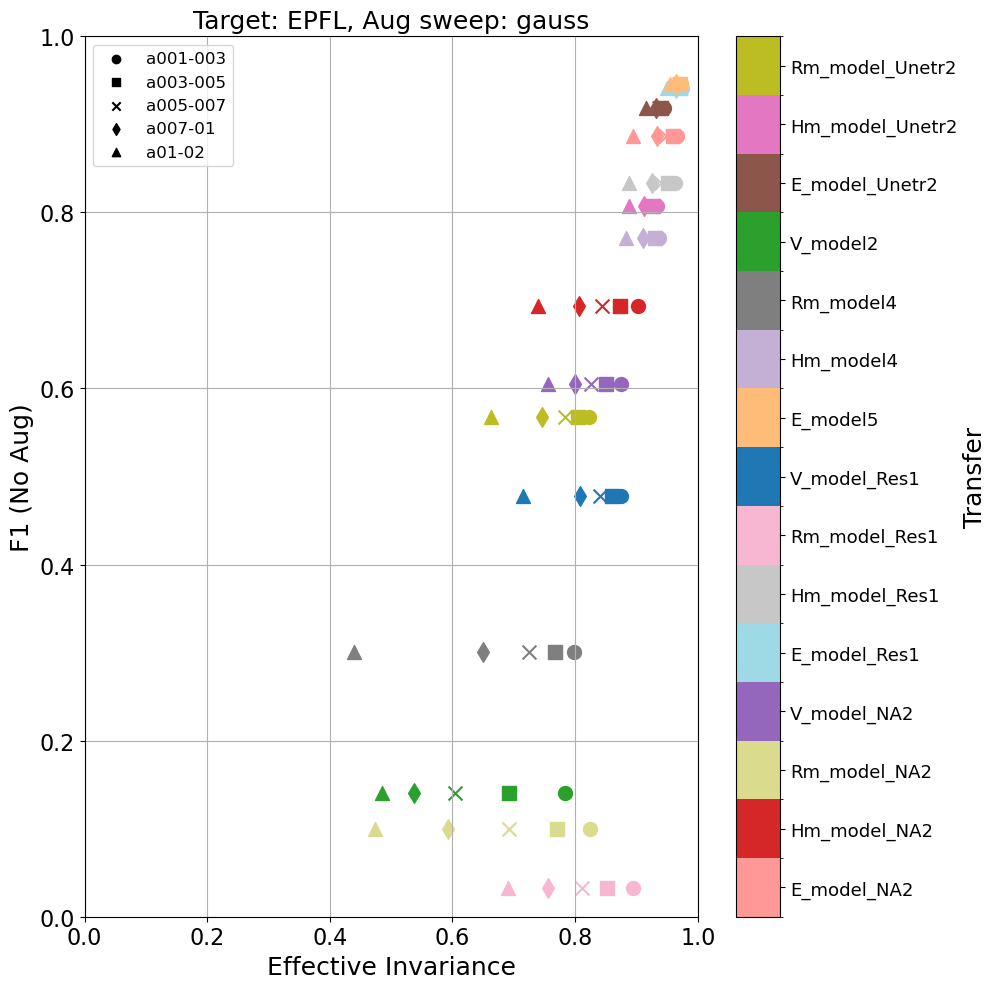

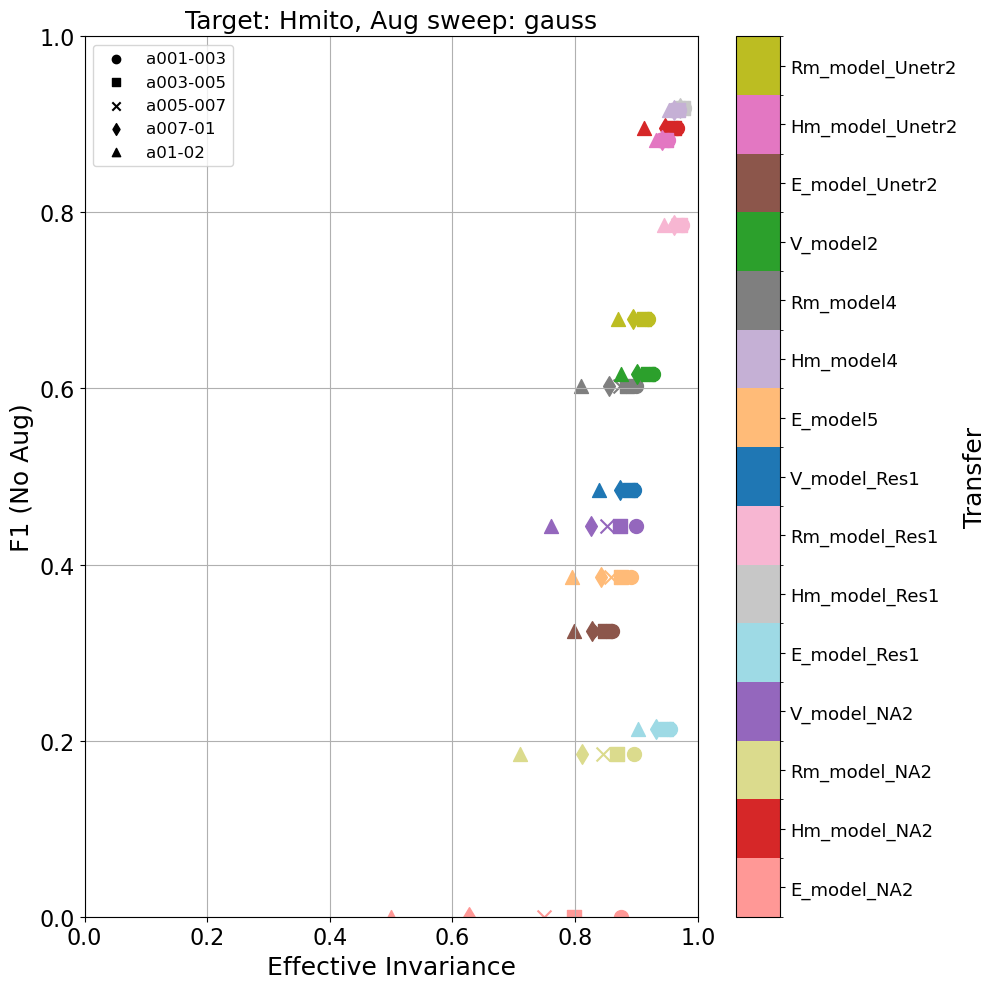

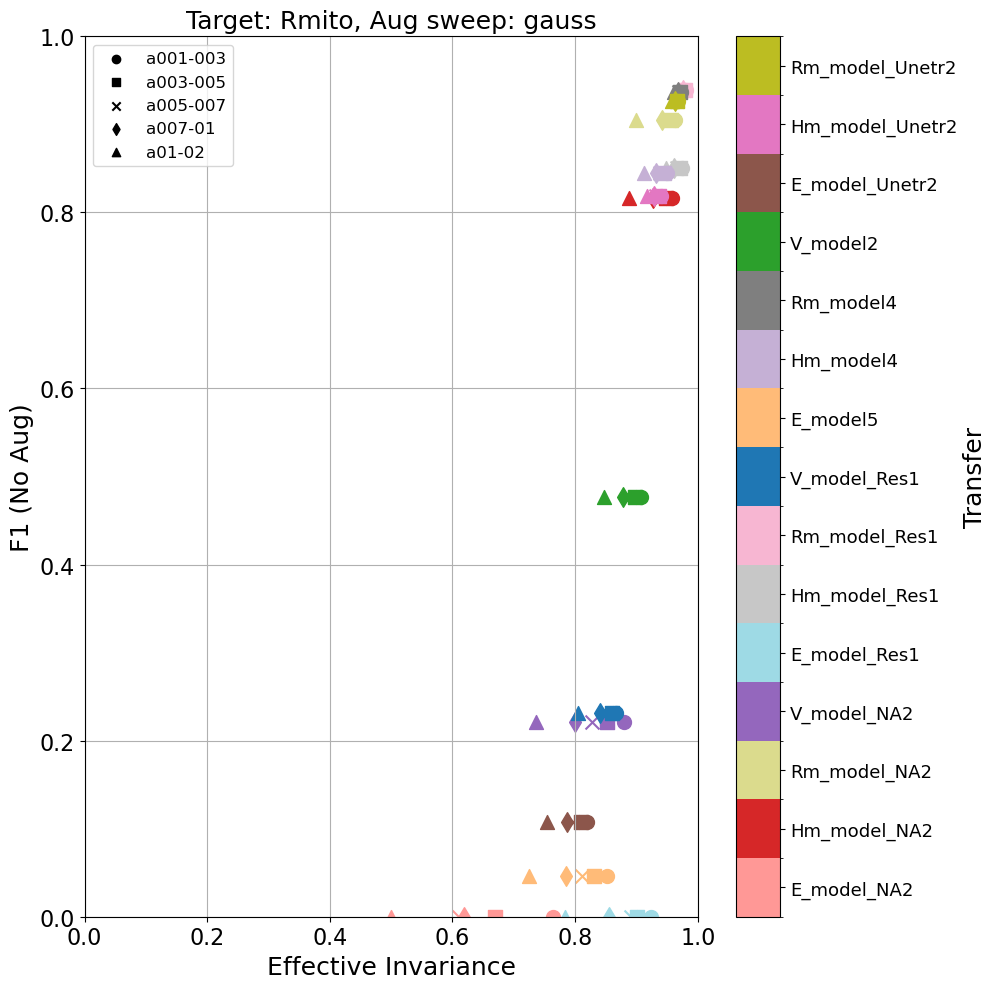

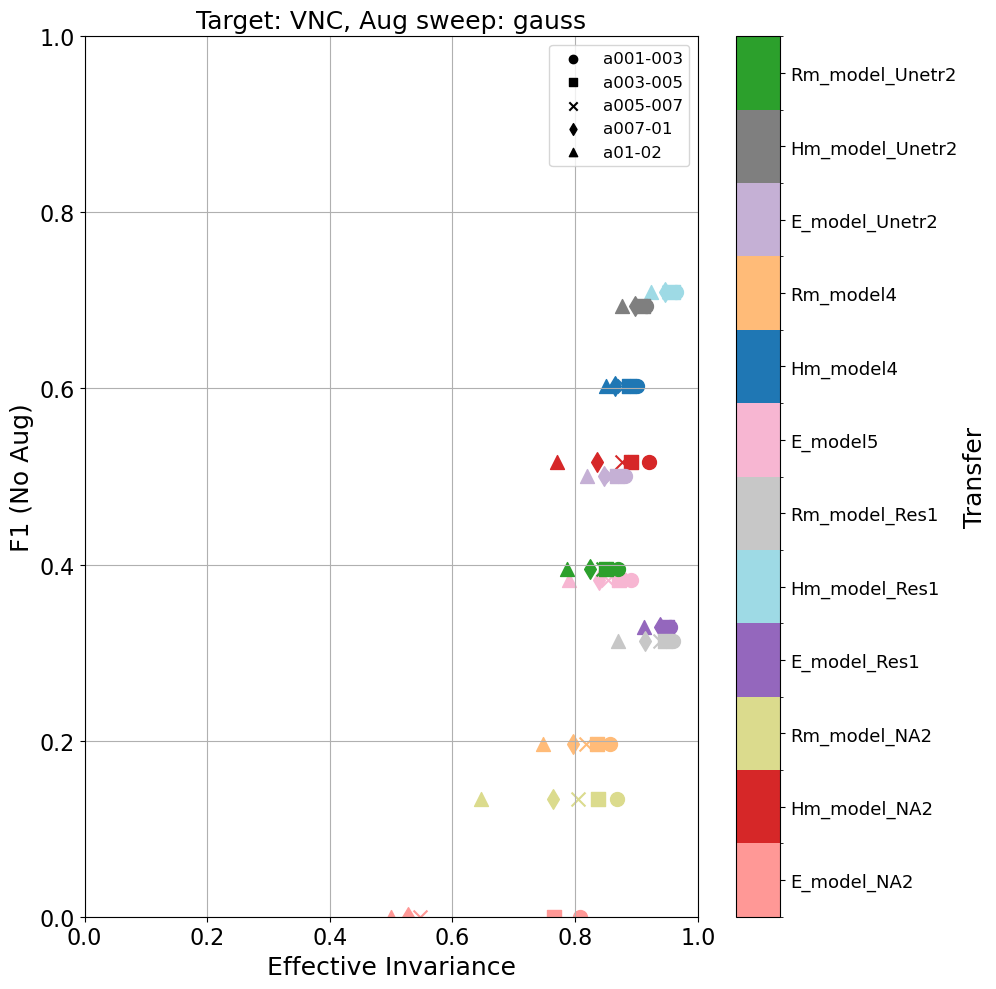

In [ ]:
selected_augmentations = {
    "none": [""],
    "gauss": ["a001-003", "a003-005", "a005-007", "a007-01", "a01-02"],
}
per_target_norms: Dict[str, List[str]] = {
    "EPFL": ["Normalize"],
    "Hmito": ["Normalize"],
    "Rmito": ["Normalize"],
    "VNC": ["Normalize"],
}

for target in consistency_scores.keys():
    plot_alpha_sweep_specific_norm(
        consistency_scores[target],
        performance_scores[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )